# TASK 1: Load & Explore the Dataset

In [8]:
pip install seaborn

Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("output.csv")
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0    Review  1000 non-null   object
 1   Liked    1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [14]:
df.value_counts("Liked")

Liked
0    500
1    500
Name: count, dtype: int64

In [15]:
df.isnull().sum()

 Review    0
Liked      0
dtype: int64

In [16]:
df['review_length'] = df[' Review'].apply(len)

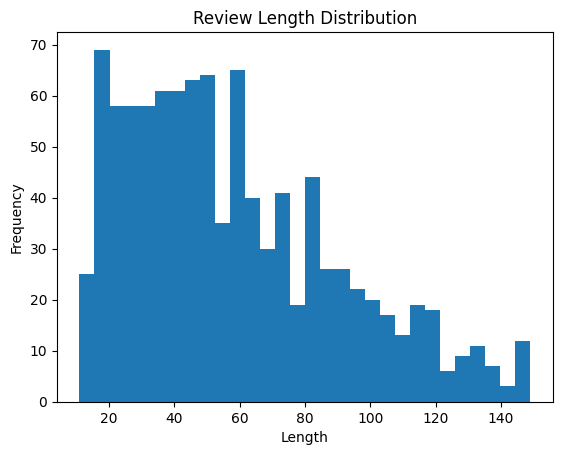

In [17]:
plt.hist(df['review_length'], bins=30)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

# TASK 2: Clean & Preprocess the Text

In [18]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df['cleaned_review'] = df[' Review'].apply(clean_text)

print(df[[' Review', 'cleaned_review']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mprav\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mprav\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                              Review  \
0                           Wow... Loved this place.   
1                                 Crust is not good.   
2          Not tasty and the texture was just nasty.   
3  Stopped by during the late May bank holiday of...   
4  The selection on the menu was great and so wer...   

                                      cleaned_review  
0                                    wow loved place  
1                                         crust good  
2                                tasty texture nasty  
3  stopped late may bank holiday rick steve recom...  
4                         selection menu great price  


# TASK 3: Convert Text to Numerical Features

## Option 1: Bag of Words

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X_bow = cv.fit_transform(df['cleaned_review'])

## Option 2: TF-IDF

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df['cleaned_review'])

### Target variable:

In [21]:
y = df['Liked']

# TASK 4: Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42)

# TASK 5: Train Naïve Bayes Model (BernoulliNB)

In [23]:
from sklearn.naive_bayes import BernoulliNB

model = BernoulliNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# TASK 6: Evaluate Model

Accuracy: 0.75
Precision: 0.75
Recall: 0.7788461538461539
F1 Score: 0.7641509433962265


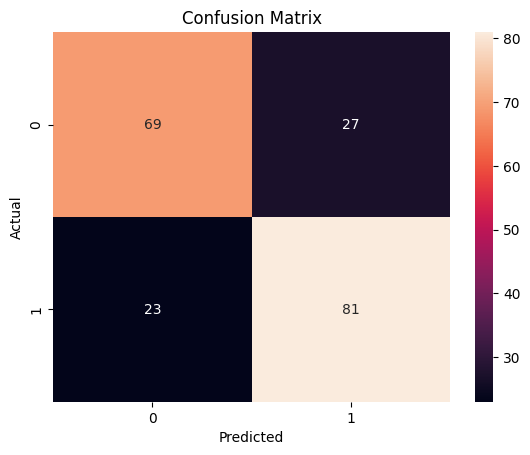


Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.72      0.73        96
           1       0.75      0.78      0.76       104

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# TASK 7: Predict New Reviews

In [25]:
sample_reviews = [
    "The food was fantastic!",
    "Worst service ever."
]

# Clean them
sample_cleaned = [clean_text(review) for review in sample_reviews]

# Convert to TF-IDF
sample_vector = tfidf.transform(sample_cleaned)

# Predict
predictions = model.predict(sample_vector)

for review, pred in zip(sample_reviews, predictions):
    sentiment = "Positive 😊" if pred == 1 else "Negative 😡"
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}\n")

Review: The food was fantastic!
Predicted Sentiment: Positive 😊

Review: Worst service ever.
Predicted Sentiment: Negative 😡



In [27]:
import pickle

In [28]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("✅ model.pkl and tfidf.pkl saved successfully!")

✅ model.pkl and tfidf.pkl saved successfully!


# Final Pipeline Version (Professional Way)

In [26]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', BernoulliNB())
])

pipeline.fit(df['cleaned_review'], df['Liked'])

,steps,"[('tfidf', ...), ('nb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
